# Modelo 12 — Seleccion de factores que mas afectan `CarrierPay`

**Objetivo:** identificar que variables descriptivas mas se relacionan / influyen sobre el pago al carrier (`CarrierPay`).

**Tres enfoques:**
1. **Importancia de un arbol de decision** (`DecisionTreeRegressor`)
2. **PCA** (loadings en componentes ligados al pricing / a CarrierPay)
3. **Correlacion** con `CarrierPay`

**Anti data leakage (en los 3):** se **elimina `CustomerPay`** de las predictoras / del analisis de factores operadores.

**Fuente:** `01_DataClean/cleaned_data_shipment.csv`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Importacion de librerias


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import metrics

## 2. Carga y verificacion de datos


In [ ]:
PATH = '/content/drive/MyDrive/5. UPB Maestría/SEMESTRE 1/02_Mineria_de_datos/PROYECTO/01_DataClean/cleaned_data_shipment.csv'

df = pd.read_csv(PATH)
print('Shape:', df.shape)
df.head()

Shape: (23975, 15)


,Mode,Equipment,Miles,CarrierPay,CustomerPay,Roll_Over,Prebook,General_Pricing_Category,Stop_Type,Origin_Zip,Destination_Zip,Total_Drops,HasTracking,Status,FallOff
0,FTL,Van,738.0,1155.00,1443.1,'Rolled Over',Prebooked,'No Category','Unique Stop',21230,60090,4,1,Delivered,FALSE
1,FTL,Van,1236.0,2137.68,2175.0,'On Time','Not Prebooked','No Category','Unique Stop',19137,55807,5,1,Delivered,FALSE
2,FTL,Van,1694.0,3195.00,3814.8,'Rolled Over',Prebooked,'No Category','Unique Stop',28396,80530,2,1,Delivered,FALSE
3,FTL,Van,688.0,2100.00,2325.0,'Rolled Over',Prebooked,'No Category','Unique Stop',29135,18202,1,1,Canceled,FALSE
4,FTL,Van,665.0,1200.00,1200.0,'Rolled Over',Prebooked,'No Category','Unique Stop',8102,46517,0,1,Canceled,FALSE


## 3. Limpieza basica


In [ ]:
df['Status'] = df['Status'].astype(str).str.strip().str.upper()
df['FallOff'] = df['FallOff'].astype(str).str.strip().str.upper()
df['FallOff'] = df['FallOff'].map({'TRUE': 1, 'FALSE': 0})

print('Nulos:', df.isnull().sum().sum())
print(df['CarrierPay'].describe().round(2))

Nulos: 0
count    23975.00
mean      1063.92
std       1233.29
min          0.00
25%          0.00
50%        800.00
75%       1553.84
max      11000.00
Name: CarrierPay, dtype: float64


## 4. Matriz comun de factores (sin `CustomerPay` ni zips)

Se construye **una sola matriz X** usada por los tres metodos, sin `CustomerPay`.


In [ ]:
y = df['CarrierPay'].copy()

x = df.drop(columns=[
    'CarrierPay',   # target / variable a explicar
    'CustomerPay',  # LEAKAGE — no se usa en ningun metodo
    'Origin_Zip',
    'Destination_Zip',
    'Status', # LEAKAGE — no se usa en ningun metodo
    'FallOff', # LEAKAGE — no se usa en ningun metodo
    'HasTracking' # LEAKAGE — no se usa en ningun metodo
])

assert 'CustomerPay' not in x.columns
assert 'CarrierPay' not in x.columns
print('OK: CustomerPay y CarrierPay fuera de X')
print('Columnas base:', list(x.columns))

x = pd.get_dummies(
    x,
    columns=['Mode', 'Equipment', 'General_Pricing_Category'],
    drop_first=False,
    dtype=float
)
x = pd.get_dummies(
    x,
    columns=['Roll_Over', 'Prebook', 'Stop_Type'],
    drop_first=True,
    dtype=float
)

feature_names = x.columns.tolist()
print('Shape X:', x.shape)
x.head()

OK: CustomerPay y CarrierPay fuera de X
Columnas base: ['Mode', 'Equipment', 'Miles', 'Roll_Over', 'Prebook', 'General_Pricing_Category', 'Stop_Type', 'Total_Drops']
Shape X: (23975, 24)


,Miles,Total_Drops,Mode_Drayage,Mode_FTL,Mode_Intermodal,Mode_LTL,Equipment_'Box Truck Reefer',Equipment_'Box Truck',Equipment_'Container Refrigerated',Equipment_'Container Trailer',...,Equipment_Stepdeck,Equipment_Van,General_Pricing_Category_'High Market Variance',General_Pricing_Category_'No Category',General_Pricing_Category_'Price Drop Trend',General_Pricing_Category_'Price Increase Trend',General_Pricing_Category_'Stable Pricing',Roll_Over_'Rolled Over',Prebook_Prebooked,Stop_Type_Multistop
0,738.0,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1236.0,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1694.0,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,688.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,665.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


---
# Metodo 1 — Importancia con Arbol de Decision


## 5. Entrenar `DecisionTreeRegressor` sobre `CarrierPay`

El arbol aprende a predecir `CarrierPay` y reporta **feature_importances_** (reduccion de impureza / MSE).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

tree = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=8,
    min_samples_leaf=40,
    random_state=42
)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print('Referencia predictiva del arbol (no es el foco, solo contexto):')
print('  MAE :', round(metrics.mean_absolute_error(y_test, y_pred), 2))
print('  RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)), 2))
print('  R2  :', round(metrics.r2_score(y_test, y_pred), 4))

Referencia predictiva del arbol (no es el foco, solo contexto):
  MAE : 580.05
  RMSE: 866.76
  R2  : 0.4956


## 6. Ranking por importancia del arbol


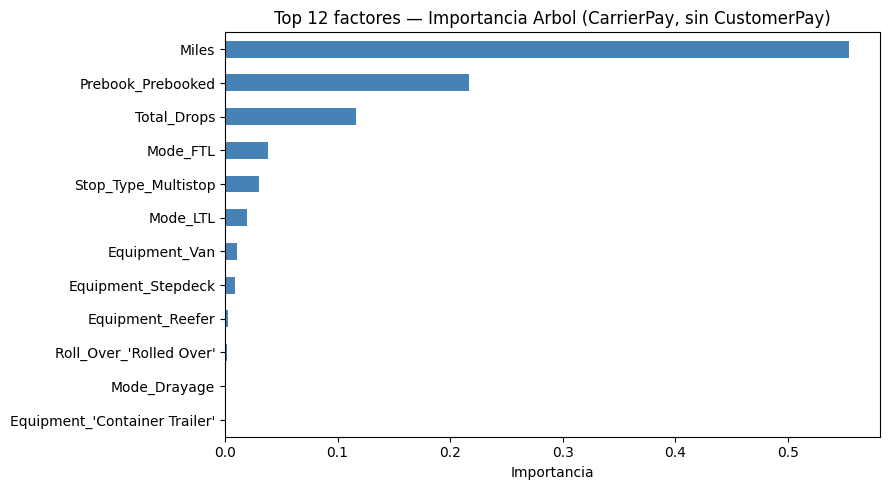

Top 12 (Arbol):


,0
Miles,0.5544
Prebook_Prebooked,0.2171
Total_Drops,0.1165
Mode_FTL,0.0383
Stop_Type_Multistop,0.0298
Mode_LTL,0.0191
Equipment_Van,0.0105
Equipment_Stepdeck,0.0089
Equipment_Reefer,0.0029
Roll_Over_'Rolled Over',0.0014


In [ ]:
imp_tree = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)
top_tree = imp_tree.head(12)

plt.figure(figsize=(9, 5))
top_tree.iloc[::-1].plot(kind='barh', color='steelblue')
plt.title('Top 12 factores — Importancia Arbol (CarrierPay, sin CustomerPay)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

rank_tree = imp_tree.rank(ascending=False)
print('Top 12 (Arbol):')
top_tree.round(4)

## 7. Resumen Metodo 1 (Arbol)

- **Que mide:** cuanto contribuye cada variable a reducir el error al predecir `CarrierPay`.
- **Ventaja:** captura relaciones no lineales e interacciones.
- **Limitacion:** es un poco supervisado (usa `CarrierPay` como y); puede sesgarse a variables con muchos cortes utiles.


In [ ]:
resumen_arbol = pd.DataFrame({
    'factor': top_tree.index,
    'importancia_arbol': top_tree.values,
    'rank_arbol': range(1, len(top_tree) + 1)
})
print('RESUMEN METODO 1 — ARBOL')
print('Variables que mas afectan CarrierPay segun el arbol:')
for i, row in resumen_arbol.iterrows():
    print(f"  {int(row['rank_arbol'])}. {row['factor']}  (imp={row['importancia_arbol']:.4f})")
resumen_arbol

RESUMEN METODO 1 — ARBOL
Variables que mas afectan CarrierPay segun el arbol:
  1. Miles  (imp=0.5005)
  2. Status_DELIVERED  (imp=0.3718)
  3. Mode_LTL  (imp=0.0693)
  4. Prebook_Prebooked  (imp=0.0194)
  5. Equipment_Stepdeck  (imp=0.0108)
  6. HasTracking  (imp=0.0085)
  7. Total_Drops  (imp=0.0084)
  8. Stop_Type_Multistop  (imp=0.0055)
  9. Equipment_Reefer  (imp=0.0015)
  10. Mode_Drayage  (imp=0.0014)
  11. Equipment_Van  (imp=0.0013)
  12. Equipment_'Straight Van'  (imp=0.0009)


,factor,importancia_arbol,rank_arbol
0,Miles,0.500456,1
1,Status_DELIVERED,0.371791,2
2,Mode_LTL,0.069310,3
3,Prebook_Prebooked,0.019363,4
4,Equipment_Stepdeck,0.010804,5
5,HasTracking,0.008498,6
6,Total_Drops,0.008413,7
7,Stop_Type_Multistop,0.005495,8
8,Equipment_Reefer,0.001471,9
9,Mode_Drayage,0.001408,10


---
# Metodo 2 — PCA


## 8. PCA sobre las predictoras (sin `CustomerPay`)

PCA no usa etiquetas: resume la covarianza de X.  
Luego se identifica que componentes se asocian mas a `CarrierPay` (correlacion PC vs y) y se rankean variables por `|loading|` en esos PCs.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

pca = PCA(random_state=42)
scores = pca.fit_transform(X_scaled)

# Cuantos componentes retener (Kaiser o hasta ~80% var, max 8)
ev = pca.explained_variance_
evr = pca.explained_variance_ratio_
n_kaiser = int((ev > 1).sum())
n_comp = int(np.clip(max(n_kaiser, 2), 2, 8))

print('Componentes Kaiser (autovalor>1):', n_kaiser)
print('Componentes usados:', n_comp)
print('Var acumulada retenida:', round(evr[:n_comp].sum(), 4))

# Correlacion de cada PC retenido con CarrierPay
pc_corr = []
for i in range(n_comp):
    pc_corr.append(np.corrcoef(scores[:, i], y.values)[0, 1])
pc_corr = pd.Series(pc_corr, index=[f'PC{i+1}' for i in range(n_comp)])
print('\nCorrelacion PC vs CarrierPay:')
print(pc_corr.round(4))

# PCs ligados al pricing: |corr| >= 0.15 (o el de mayor |corr|)
pcs_pricing = pc_corr[pc_corr.abs() >= 0.15].index.tolist()
if not pcs_pricing:
    pcs_pricing = [pc_corr.abs().idxmax()]
print('PCs ligados a CarrierPay:', pcs_pricing)

Componentes Kaiser (autovalor>1): 14
Componentes usados: 8
Var acumulada retenida: 0.5254

Correlacion PC vs CarrierPay:
PC1   -0.2153
PC2   -0.0913
PC3    0.4671
PC4   -0.0177
PC5    0.2802
PC6    0.1228
PC7   -0.1409
PC8   -0.0270
dtype: float64
PCs ligados a CarrierPay: ['PC1', 'PC3', 'PC5']


## 9. Loadings y ranking PCA


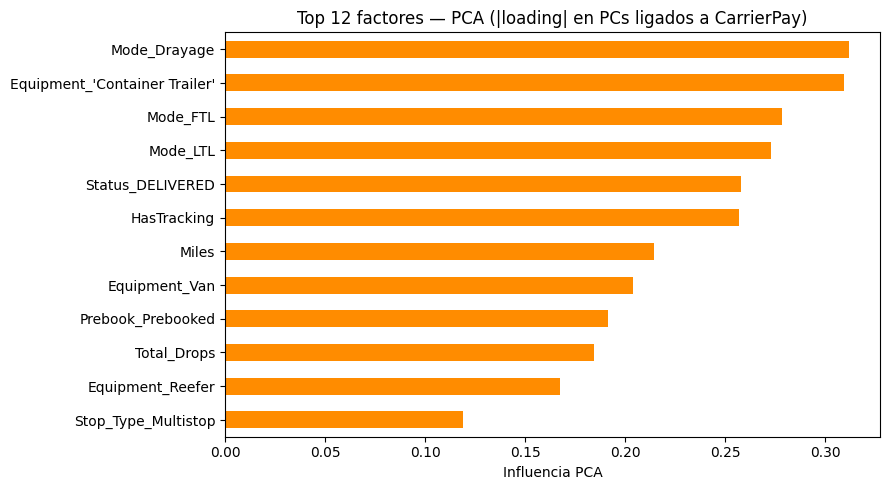

Top 12 (PCA):


,0
Mode_Drayage,0.3119
Equipment_'Container Trailer',0.3094
Mode_FTL,0.2788
Mode_LTL,0.2731
Status_DELIVERED,0.2579
HasTracking,0.2568
Miles,0.2147
Equipment_Van,0.2042
Prebook_Prebooked,0.1917
Total_Drops,0.1847


In [ ]:
loadings = pd.DataFrame(
    pca.components_[:n_comp].T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(n_comp)]
)

# Influencia = media de |loadings| en PCs ligados a CarrierPay
imp_pca = loadings[pcs_pricing].abs().mean(axis=1).sort_values(ascending=False)
top_pca = imp_pca.head(12)

plt.figure(figsize=(9, 5))
top_pca.iloc[::-1].plot(kind='barh', color='darkorange')
plt.title('Top 12 factores — PCA (|loading| en PCs ligados a CarrierPay)')
plt.xlabel('Influencia PCA')
plt.tight_layout()
plt.show()

rank_pca = imp_pca.rank(ascending=False)
print('Top 12 (PCA):')
top_pca.round(4)

## 10. Resumen Metodo 2 (PCA)

- **Que mide:** variables que mas pesan en las dimensiones latentes asociadas a `CarrierPay`.
- **Ventaja:** no supervisado sobre X; reduce multicolinealidad.
- **Limitacion:** componentes son combinaciones lineales; la interpretacion es por loadings.


In [ ]:
resumen_pca = pd.DataFrame({
    'factor': top_pca.index,
    'influencia_pca': top_pca.values,
    'rank_pca': range(1, len(top_pca) + 1)
})
print('RESUMEN METODO 2 — PCA')
print('Variables que mas afectan CarrierPay segun PCA:')
for _, row in resumen_pca.iterrows():
    print(f"  {int(row['rank_pca'])}. {row['factor']}  (infl={row['influencia_pca']:.4f})")
resumen_pca

RESUMEN METODO 2 — PCA
Variables que mas afectan CarrierPay segun PCA:
  1. Mode_Drayage  (infl=0.3119)
  2. Equipment_'Container Trailer'  (infl=0.3094)
  3. Mode_FTL  (infl=0.2788)
  4. Mode_LTL  (infl=0.2731)
  5. Status_DELIVERED  (infl=0.2579)
  6. HasTracking  (infl=0.2568)
  7. Miles  (infl=0.2147)
  8. Equipment_Van  (infl=0.2042)
  9. Prebook_Prebooked  (infl=0.1917)
  10. Total_Drops  (infl=0.1847)
  11. Equipment_Reefer  (infl=0.1676)
  12. Stop_Type_Multistop  (infl=0.1192)


,factor,influencia_pca,rank_pca
0,Mode_Drayage,0.311939,1
1,Equipment_'Container Trailer',0.309442,2
2,Mode_FTL,0.278755,3
3,Mode_LTL,0.273121,4
4,Status_DELIVERED,0.257864,5
5,HasTracking,0.256823,6
6,Miles,0.214676,7
7,Equipment_Van,0.204173,8
8,Prebook_Prebooked,0.191710,9
9,Total_Drops,0.184677,10


---
# Metodo 3 — Correlacion con el pricing (`CarrierPay`)


## 11. Correlacion absoluta de cada factor con `CarrierPay`

Metodo mas directo: `|corr(variable, CarrierPay)|`.  
Sigue sin usar `CustomerPay`.


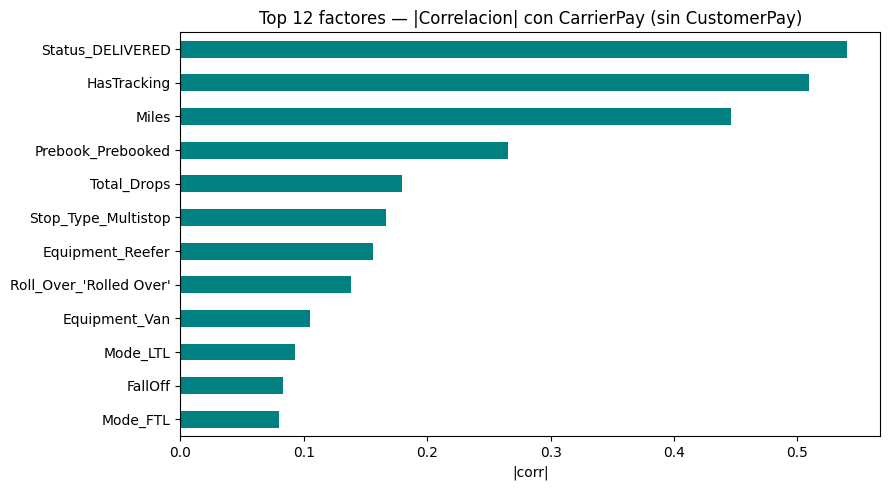

Top 12 (Correlacion):


,0
Status_DELIVERED,0.5400
HasTracking,0.5092
Miles,0.4463
Prebook_Prebooked,0.2656
Total_Drops,0.1792
Stop_Type_Multistop,0.1662
Equipment_Reefer,0.1558
Roll_Over_'Rolled Over',0.1378
Equipment_Van,0.1049
Mode_LTL,0.0927


In [ ]:
corr = x.apply(lambda col: col.corr(y)).abs().sort_values(ascending=False)
# por si alguna columna constante
corr = corr.replace([np.inf, -np.inf], np.nan).dropna()
imp_corr = corr
top_corr = imp_corr.head(12)

plt.figure(figsize=(9, 5))
top_corr.iloc[::-1].plot(kind='barh', color='teal')
plt.title('Top 12 factores — |Correlacion| con CarrierPay (sin CustomerPay)')
plt.xlabel('|corr|')
plt.tight_layout()
plt.show()

rank_corr = imp_corr.rank(ascending=False)
print('Top 12 (Correlacion):')
top_corr.round(4)

## 12. Resumen Metodo 3 (Correlacion)

- **Que mide:** asociacion lineal directa con `CarrierPay`.
- **Ventaja:** simple, interpretable, rapida.
- **Limitacion:** solo relaciones lineales; no captura interacciones.


In [ ]:
resumen_corr = pd.DataFrame({
    'factor': top_corr.index,
    'abs_corr': top_corr.values,
    'rank_corr': range(1, len(top_corr) + 1)
})
print('RESUMEN METODO 3 — CORRELACION')
print('Variables que mas afectan CarrierPay segun |corr|:')
for _, row in resumen_corr.iterrows():
    print(f"  {int(row['rank_corr'])}. {row['factor']}  (|corr|={row['abs_corr']:.4f})")
resumen_corr

RESUMEN METODO 3 — CORRELACION
Variables que mas afectan CarrierPay segun |corr|:
  1. Status_DELIVERED  (|corr|=0.5400)
  2. HasTracking  (|corr|=0.5092)
  3. Miles  (|corr|=0.4463)
  4. Prebook_Prebooked  (|corr|=0.2656)
  5. Total_Drops  (|corr|=0.1792)
  6. Stop_Type_Multistop  (|corr|=0.1662)
  7. Equipment_Reefer  (|corr|=0.1558)
  8. Roll_Over_'Rolled Over'  (|corr|=0.1378)
  9. Equipment_Van  (|corr|=0.1049)
  10. Mode_LTL  (|corr|=0.0927)
  11. FallOff  (|corr|=0.0835)
  12. Mode_FTL  (|corr|=0.0800)


,factor,abs_corr,rank_corr
0,Status_DELIVERED,0.539990,1
1,HasTracking,0.509222,2
2,Miles,0.446337,3
3,Prebook_Prebooked,0.265635,4
4,Total_Drops,0.179165,5
5,Stop_Type_Multistop,0.166192,6
6,Equipment_Reefer,0.155804,7
7,Roll_Over_'Rolled Over',0.137832,8
8,Equipment_Van,0.104910,9
9,Mode_LTL,0.092724,10


---
# Comparacion final de los 3 metodos


## 13. Tabla comparativa (ranks) y consenso

Se unen los ranks de Arbol, PCA y Correlacion.  
**Rank combinado** = promedio de ranks (menor = mas importante de forma consensuada).


In [ ]:
comparacion = pd.DataFrame({
    'imp_arbol': imp_tree,
    'rank_arbol': rank_tree,
    'imp_pca': imp_pca,
    'rank_pca': rank_pca,
    'abs_corr': imp_corr,
    'rank_corr': rank_corr,
}).dropna(how='any')

comparacion['rank_promedio'] = comparacion[['rank_arbol', 'rank_pca', 'rank_corr']].mean(axis=1)
comparacion = comparacion.sort_values('rank_promedio')

top_final = comparacion.head(15)
print('TOP 15 consensuado (menor rank_promedio = mas relevante):')
top_final[['rank_arbol', 'rank_pca', 'rank_corr', 'rank_promedio', 'imp_arbol', 'imp_pca', 'abs_corr']].round(4)

## 14. Grafico comparativo de ranks (top consensuado)


In [ ]:
plot_df = top_final.head(10)[['rank_arbol', 'rank_pca', 'rank_corr']]
ax = plot_df.plot(kind='barh', figsize=(10, 6))
ax.invert_yaxis()
plt.xlabel('Rank (1 = mas importante)')
plt.title('Comparacion de ranks — Arbol vs PCA vs Correlacion')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 15. Resumen por modelo + resumen final


In [ ]:
print('=' * 72)
print('RESUMEN POR MODELO')
print('=' * 72)

print('\n1) ARBOL DE DECISION')
print('   Idea: importancia al predecir CarrierPay (sin CustomerPay).')
print('   Top 5:')
for i, f in enumerate(top_tree.head(5).index, 1):
    print(f'      {i}. {f}')

print('\n2) PCA')
print(f'   Idea: |loadings| en PCs asociados a CarrierPay ({pcs_pricing}).')
print('   Top 5:')
for i, f in enumerate(top_pca.head(5).index, 1):
    print(f'      {i}. {f}')

print('\n3) CORRELACION')
print('   Idea: |corr| lineal directa con CarrierPay (sin CustomerPay).')
print('   Top 5:')
for i, f in enumerate(top_corr.head(5).index, 1):
    print(f'      {i}. {f}')

print('\n' + '=' * 72)
print('RESUMEN FINAL COMPARATIVO')
print('=' * 72)
print('Factores con mayor consenso entre los 3 metodos (top 8):')
for i, f in enumerate(top_final.head(8).index, 1):
    r = top_final.loc[f]
    print(
        f"  {i}. {f}\n"
        f"      ranks -> Arbol:{int(r['rank_arbol'])} | PCA:{int(r['rank_pca'])} | Corr:{int(r['rank_corr'])} "
        f"| promedio:{r['rank_promedio']:.1f}"
    )

# Factores que aparecen en el top 10 de al menos 2 metodos
set_t = set(top_tree.head(10).index)
set_p = set(top_pca.head(10).index)
set_c = set(top_corr.head(10).index)
en_dos_o_mas = sorted((set_t & set_p) | (set_t & set_c) | (set_p & set_c))
en_tres = sorted(set_t & set_p & set_c)

print('\nAparecen en el top 10 de al menos 2 metodos:')
for f in en_dos_o_mas:
    print('  -', f)
print('\nAparecen en el top 10 de los 3 metodos:')
print('  -', ', '.join(en_tres) if en_tres else '  (ninguna en comun exacta en top 10 de los 3)')

print('\nNota: en todos los metodos se excluyo CustomerPay para evitar data leakage.')